In [19]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2' 

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.utils import  energy2wavelength
from temgym_core.gaussian import GaussianRayBeta, TaylorExpofAction
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper, evaluate_gaussians_jax_scan
from temgym_core.gaussian_taylor import (
    Lens,
    SigmoidAperture,
    run_to_end,

)
from temgym_core.utils import fibonacci_spiral

jax.config.update("jax_enable_x64", True)

In [ ]:
voltage = 100000  # in volts
wavelength = energy2wavelength(voltage)  # in meters
print(wavelength)
input_window_width = 1e-7
aperture_radius = 1.0e-7
aperture_window_width = 2*aperture_radius
lens_f = 1e-2

Nx = Ny = 1024
input_aperture_pixel_size_x = input_window_width/Nx
input_aperture_pixel_size_y = input_window_width/Ny

output_aperture_pixel_size_bfp_xy = wavelength * abs(lens_f) / (aperture_window_width)

print(output_aperture_pixel_size_bfp_xy)

input_aperture_grid = Detector(z=0.0, pixel_size=(input_aperture_pixel_size_x, input_aperture_pixel_size_y), shape=(Nx, Ny))

coords = input_aperture_grid.coords
X, Y = coords[:,0].reshape(input_aperture_grid.shape), coords[:,1].reshape(input_aperture_grid.shape)
x, y = X[0,:], Y[:,0]
extent = (x[0], x[-1], y[0], y[-1])


aperture = SigmoidAperture(radius=aperture_radius, sharpness=1000, z=0.0, t_outside=0.0)

3.7014365951263735e-12
3.7014365951263735e-07


In [21]:
wavelength = energy2wavelength(voltage)
k0 = 2 * jnp.pi / wavelength
num_rays = 50000

key1, key2 = jax.random.PRNGKey(0), jax.random.PRNGKey(1)
num_rays_sqrt = int(jnp.ceil(jnp.sqrt(num_rays)))

rx, ry = fibonacci_spiral(num_rays, radius=0.1e-7)
w0 = 1e-9
q = 1j * (wavelength / (np.pi * w0**2))
Q_inv = jnp.array([[q, 0.0], [0.0, q]])
Q_inv = jnp.tile(Q_inv, (num_rays, 1, 1))

#area of aperture
aperture_area = np.pi * aperture.radius**2
scale_factor = aperture_area / (w0 ** 2 * num_rays * np.pi)
C0 = jnp.ones(num_rays) * (1.0 * scale_factor + 0.0j)
eta = jnp.full((num_rays, 2), 0.0+0.0j)

voltage = jnp.full((num_rays,), voltage)

S = TaylorExpofAction(
    const=jnp.zeros(num_rays, dtype=jnp.complex128),
    lin=jnp.zeros((num_rays, 2), dtype=jnp.complex128),
    quad=Q_inv,
)
rays_in = GaussianRayBeta(x=rx, 
                         y=ry, 
                         dx=jnp.zeros(num_rays), 
                         dy=jnp.zeros(num_rays), 
                         z=jnp.zeros(num_rays), 
                         pathlength=jnp.zeros(num_rays),
                         _one=jnp.ones(num_rays),
                         C=C0,
                         S=S,
                         voltage=voltage)

rays_in.to_vector()

# Create JIT-ed single-ray and VMAP-ed batched versions without overwriting the original
run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)),
    static_argnums=(1,),
)

In [22]:
from temgym_core.evaluate import evaluate_gaussians_for


rays_out = run_to_end_vmapped(rays_in, (aperture,))
input_aperture_image =  evaluate_gaussians_gpu_kernel_wrapper(rays_out, input_aperture_grid).block_until_ready()
# input_aperture_image = evaluate_gaussians_for(rays_out, input_aperture_grid)

In [23]:
lens = Lens(z=lens_f, focal_length=lens_f)
output_probe_grid = Detector(z=lens_f * 2, pixel_size=(output_aperture_pixel_size_bfp_xy, output_aperture_pixel_size_bfp_xy), shape=(Nx, Ny))
components = (aperture, lens, output_probe_grid)
rays_out = run_to_end_vmapped(rays_in, components)

In [24]:
probe_image = evaluate_gaussians_gpu_kernel_wrapper(rays_out, output_probe_grid).block_until_ready()

Text(0.5, 1.0, 'Input Aperture Intensity')

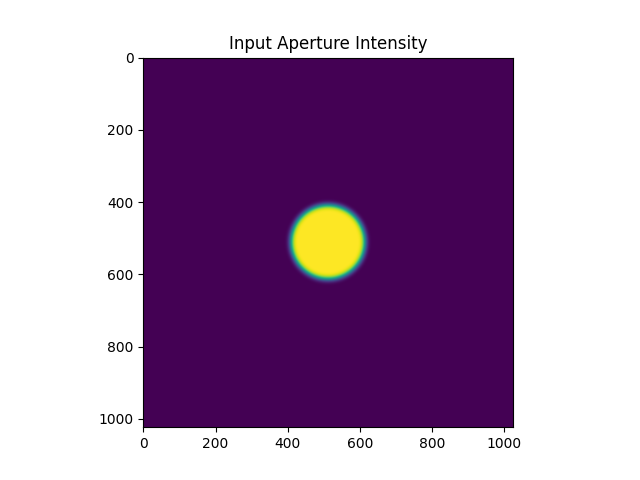

In [25]:

plt.figure()
plt.imshow(jnp.abs(input_aperture_image))
plt.title('Input Aperture Intensity')

Text(0.5, 1.0, 'Probe intensity (a.u.)')

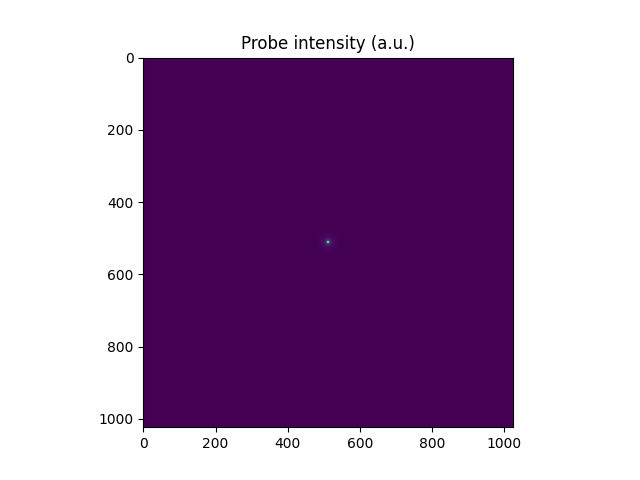

In [26]:
plt.figure()
plt.imshow(jnp.abs(probe_image))
plt.title('Probe intensity (a.u.)')

In [27]:
# du, dv = aperture_pixel_size_x, aperture_pixel_size_y
# diffraction_of_aperture = jnp.fft.ifftshift(jnp.fft.fft2(aperture_image)) * (du * dv) / (1j * wavelength * B) # Very important energy conservation factor
# det_image_in_focus = jnp.abs(diffraction_of_aperture)